In [2]:
import kagglehub

path = kagglehub.dataset_download(
    "lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes"
)

print("Dataset Path:", path)

Using Colab cache for faster access to the 'road-damage-dataset-potholes-cracks-and-manholes' dataset.
Dataset Path: /kaggle/input/road-damage-dataset-potholes-cracks-and-manholes


In [3]:
import os

print(os.listdir(path))

['data']


In [4]:
data_path = os.path.join(path, "data")

print(os.listdir(data_path))

['COCO-conversion-script.py', 'labels', 'annotations_coco.json', 'README.md', 'YOLO-conversion-script.py', 'images', 'labels-YOLO']


In [5]:
import json
import pandas as pd
import os

annotation_path = os.path.join(
    path,
    "data",
    "annotations_coco.json"
)

with open(annotation_path, "r") as f:
    coco = json.load(f)

print("Loaded Successfully")

print("\nAvailable Keys:")
print(coco.keys())

Loaded Successfully

Available Keys:
dict_keys(['images', 'annotations', 'categories'])


In [6]:
df_images = pd.DataFrame(coco["images"])

df_annotations = pd.DataFrame(coco["annotations"])

df_categories = pd.DataFrame(coco["categories"])

In [7]:
print("\nImages")
display(df_images.head())

print("\nAnnotations")
display(df_annotations.head())

print("\nCategories")
display(df_categories)


Images


,id,file_name,width,height
0,1,20250216_164325.jpg,640,360
1,2,20250216_164521.jpg,640,360
2,3,20250216_164541.jpg,640,360
3,4,20250219_164649.jpg,640,360
4,5,20250219_164714.jpg,640,360



Annotations


,id,image_id,category_id,bbox,area,iscrowd
0,1,1,2,"[203.00032000000002, 173.00016, 190.9996799999...",9931.95280,0
1,2,1,0,"[372.99968, 180.0, 28.000639999999976, 41.0000...",1148.02736,0
2,3,1,0,"[166.0, 186.00011999999998, 32.99968000000001,...",659.98700,0
3,4,1,0,"[231.00032, 171.0, 33.999360000000024, 16.9999...",577.98640,0
4,5,1,1,"[254.0, 226.00007999999997, 32.0, 32.000040000...",1024.00128,0



Categories


,id,name
0,0,pothole
1,1,crack
2,2,manhole


In [8]:
num_classes = len(df_categories)

print("Total Classes:", num_classes)

display(df_categories)

Total Classes: 3


,id,name
0,0,pothole
1,1,crack
2,2,manhole


In [9]:
class_counts = (
    df_annotations["category_id"]
    .value_counts()
)

print(class_counts)

category_id
1    2519
0    1261
2     957
Name: count, dtype: int64


In [10]:
mapping = dict(
    zip(
        df_categories["id"],
        df_categories["name"]
    )
)

class_counts.index = (
    class_counts.index
    .map(mapping)
)

print(class_counts)

category_id
crack      2519
pothole    1261
manhole     957
Name: count, dtype: int64


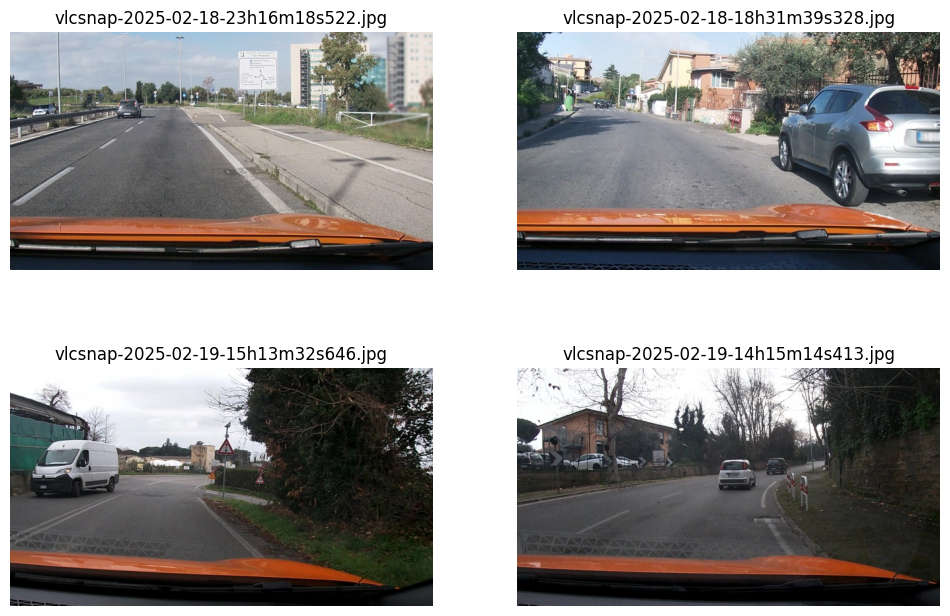

In [11]:
from PIL import Image
import matplotlib.pyplot as plt
import random

image_folder = os.path.join(
    path,
    "data",
    "images"
)

sample = random.sample(
    coco["images"],
    4
)

plt.figure(figsize=(12,8))

for i,img in enumerate(sample):

    img_path = os.path.join(
        image_folder,
        img["file_name"]
    )

    image = Image.open(img_path)

    plt.subplot(2,2,i+1)

    plt.imshow(image)

    plt.title(img["file_name"])

    plt.axis("off")

plt.show()

## PreProcesssing..

In [12]:
# Merge image and annotation data

df = (
    df_annotations
    .merge(
        df_images,
        left_on="image_id",
        right_on="id"
    )
)

df.head()

,id_x,image_id,category_id,bbox,area,iscrowd,id_y,file_name,width,height
0,1,1,2,"[203.00032000000002, 173.00016, 190.9996799999...",9931.95280,0,1,20250216_164325.jpg,640,360
1,2,1,0,"[372.99968, 180.0, 28.000639999999976, 41.0000...",1148.02736,0,1,20250216_164325.jpg,640,360
2,3,1,0,"[166.0, 186.00011999999998, 32.99968000000001,...",659.98700,0,1,20250216_164325.jpg,640,360
3,4,1,0,"[231.00032, 171.0, 33.999360000000024, 16.9999...",577.98640,0,1,20250216_164325.jpg,640,360
4,5,1,1,"[254.0, 226.00007999999997, 32.0, 32.000040000...",1024.00128,0,1,20250216_164325.jpg,640,360


In [13]:
print(df.columns)

Index(['id_x', 'image_id', 'category_id', 'bbox', 'area', 'iscrowd', 'id_y',
       'file_name', 'width', 'height'],
      dtype='object')


In [14]:
category_map = (
    df_categories
    .set_index("id")
    ["name"]
    .to_dict()
)

df["label"] = (
    df["category_id"]
    .map(category_map)
)

df[["file_name","label"]].head()

,file_name,label
0,20250216_164325.jpg,manhole
1,20250216_164325.jpg,pothole
2,20250216_164325.jpg,pothole
3,20250216_164325.jpg,pothole
4,20250216_164325.jpg,crack


In [15]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["encoded_label"] = (
    encoder.fit_transform(
        df["label"]
    )
)

print(
    dict(
        zip(
            encoder.classes_,
            encoder.transform(
                encoder.classes_
            )
        )
    )
)

{'crack': np.int64(0), 'manhole': np.int64(1), 'pothole': np.int64(2)}


In [16]:
image_dir = os.path.join(
    path,
    "data",
    "images"
)

df["path"] = (
    image_dir
    + "/"
    + df["file_name"]
)

df.head()

,id_x,image_id,category_id,bbox,area,iscrowd,id_y,file_name,width,height,label,encoded_label,path
0,1,1,2,"[203.00032000000002, 173.00016, 190.9996799999...",9931.95280,0,1,20250216_164325.jpg,640,360,manhole,1,/kaggle/input/road-damage-dataset-potholes-cra...
1,2,1,0,"[372.99968, 180.0, 28.000639999999976, 41.0000...",1148.02736,0,1,20250216_164325.jpg,640,360,pothole,2,/kaggle/input/road-damage-dataset-potholes-cra...
2,3,1,0,"[166.0, 186.00011999999998, 32.99968000000001,...",659.98700,0,1,20250216_164325.jpg,640,360,pothole,2,/kaggle/input/road-damage-dataset-potholes-cra...
3,4,1,0,"[231.00032, 171.0, 33.999360000000024, 16.9999...",577.98640,0,1,20250216_164325.jpg,640,360,pothole,2,/kaggle/input/road-damage-dataset-potholes-cra...
4,5,1,1,"[254.0, 226.00007999999997, 32.0, 32.000040000...",1024.00128,0,1,20250216_164325.jpg,640,360,crack,0,/kaggle/input/road-damage-dataset-potholes-cra...


In [17]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["encoded_label"]
)

print("Train:",len(train_df))
print("Test:",len(test_df))

Train: 3789
Test: 948


In [18]:
import cv2
import numpy as np

IMG_SIZE = 224


def preprocess(path):

    img = cv2.imread(path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    img = cv2.resize(
        img,
        (IMG_SIZE,IMG_SIZE)
    )

    img = img / 255.0

    return img

In [19]:
X_train = np.array([
    preprocess(i)
    for i in train_df["path"]
])

y_train = np.array(
    train_df["encoded_label"]
)

X_test = np.array([
    preprocess(i)
    for i in test_df["path"]
])

y_test = np.array(
    test_df["encoded_label"]
)

print(X_train.shape)
print(y_train.shape)

(3789, 224, 224, 3)
(3789,)


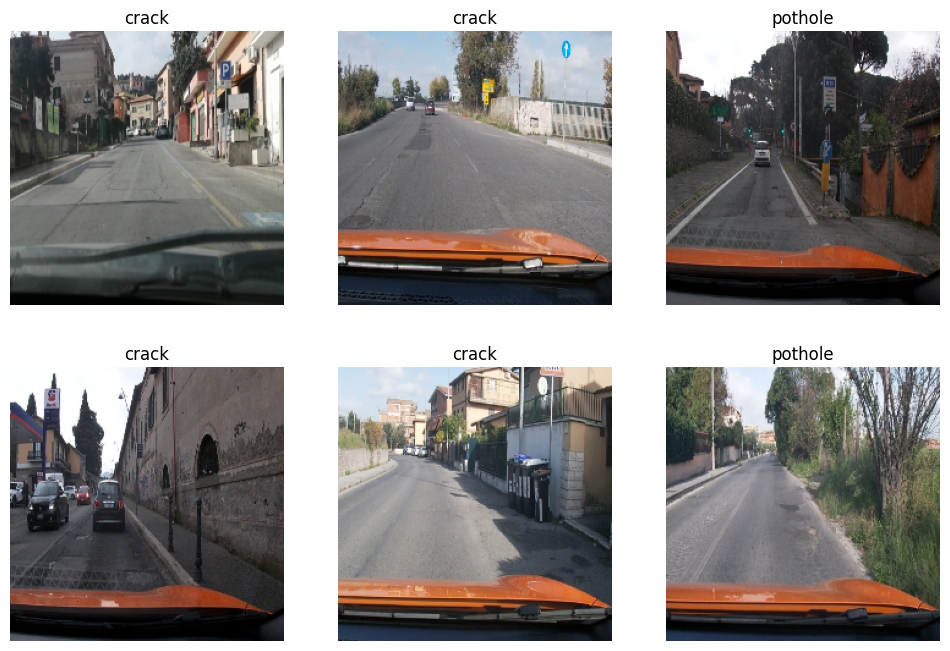

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(
        X_train[i]
    )

    plt.title(
        encoder.inverse_transform(
            [y_train[i]]
        )[0]
    )

    plt.axis("off")

plt.show()

In [21]:
import tensorflow as tf

from tensorflow.keras import layers

In [22]:
data_augmentation = tf.keras.Sequential([

    layers.RandomRotation(
        0.15
    ),

    layers.RandomZoom(
        0.20
    ),

    layers.RandomFlip(
        "horizontal"
    ),

    layers.RandomBrightness(
        0.20
    )

])

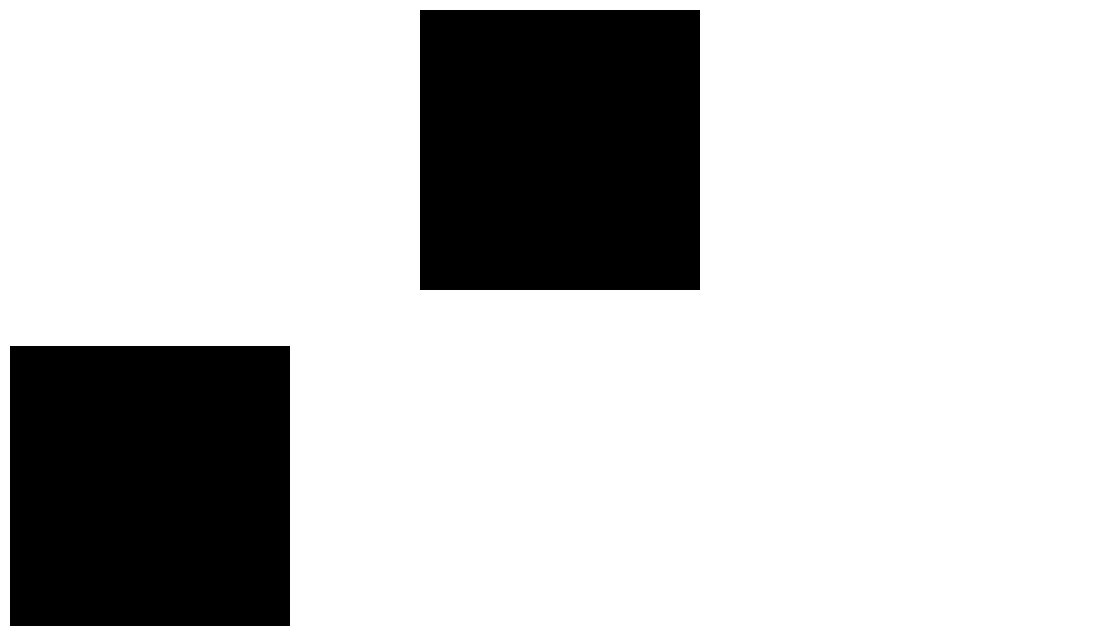

In [23]:
import matplotlib.pyplot as plt

sample = X_train[0]

plt.figure(
    figsize=(15,8)
)

for i in range(6):

    augmented = (
        data_augmentation(
            tf.expand_dims(
                sample,
                0
            )
        )
    )

    plt.subplot(
        2,
        3,
        i+1
    )

    plt.imshow(
        augmented[0]
    )

    plt.axis("off")

plt.show()

In [25]:
BATCH_SIZE = 8    # reduce memory usage

train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_df["path"],
        train_df["encoded_label"]
    )
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (
        test_df["path"],
        test_df["encoded_label"]
    )
)

In [26]:
def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        (224,224)
    )

    image = image / 255.0

    return image, label

In [27]:
train_ds = (
    train_ds
    .map(load_image)
    .batch(BATCH_SIZE)
)

test_ds = (
    test_ds
    .map(load_image)
    .batch(BATCH_SIZE)
)

In [28]:
for images, labels in train_ds.take(1):

    print(images.shape)

(8, 224, 224, 3)


# **CNN Architecture**

In [29]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [30]:
model = Sequential([

    # Block 1
    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(224,224,3)
    ),

    MaxPooling2D(
        (2,2)
    ),


    # Block 2
    Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    MaxPooling2D(
        (2,2)
    ),


    # Block 3
    Conv2D(
        128,
        (3,3),
        activation="relu"
    ),

    MaxPooling2D(
        (2,2)
    ),


    Flatten(),


    Dense(
        128,
        activation="relu"
    ),


    Dropout(
        0.5
    ),


    Dense(
        len(df_categories),
        activation="softmax"
    )

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [32]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
import tensorflow as tf

print(
    tf.config.list_physical_devices(
        "GPU"
    )
)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [36]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True

)

In [37]:
history = model.fit(

    train_ds,

    epochs=15,

    validation_data=test_ds,

    callbacks=[early_stop]

)

Epoch 1/15
474/474 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.6659 - loss: 0.7415 - val_accuracy: 0.5970 - val_loss: 0.9120
Epoch 2/15
474/474 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.6973 - loss: 0.7074 - val_accuracy: 0.5844 - val_loss: 0.9419
Epoch 3/15
474/474 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.7208 - loss: 0.6583 - val_accuracy: 0.5759 - val_loss: 0.9788
Epoch 4/15
474/474 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.7501 - loss: 0.5953 - val_accuracy: 0.5865 - val_loss: 0.9738
Epoch 5/15
474/474 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.7648 - loss: 0.5662 - val_accuracy: 0.5907 - val_loss: 1.0389
Epoch 6/15
474/474 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.7749 - loss: 0.5482 - val_accuracy: 0.5897 - val_loss: 1.1634
Epoch 7/15
474/474 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.7992 - loss: 0.4971 - val_accuracy: 0.5823 - val_loss: 1.1977
Epoch 8/15
474/474 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.8263 - loss: 0.4512 - 

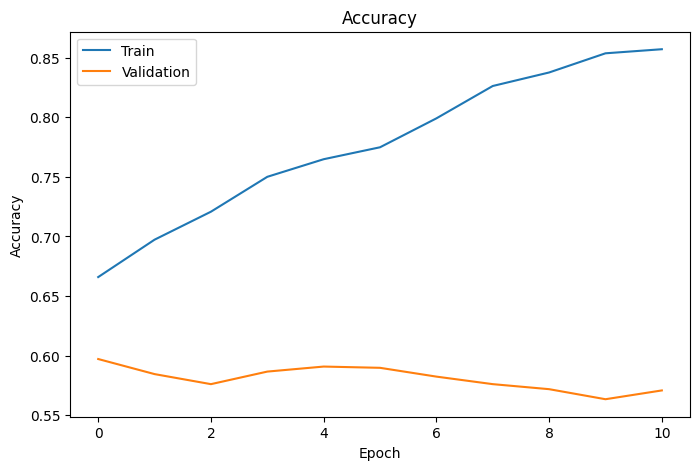

In [38]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"]
)

plt.plot(
    history.history["val_accuracy"]
)

plt.title(
    "Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.legend(
    [
        "Train",
        "Validation"
    ]
)

plt.show()

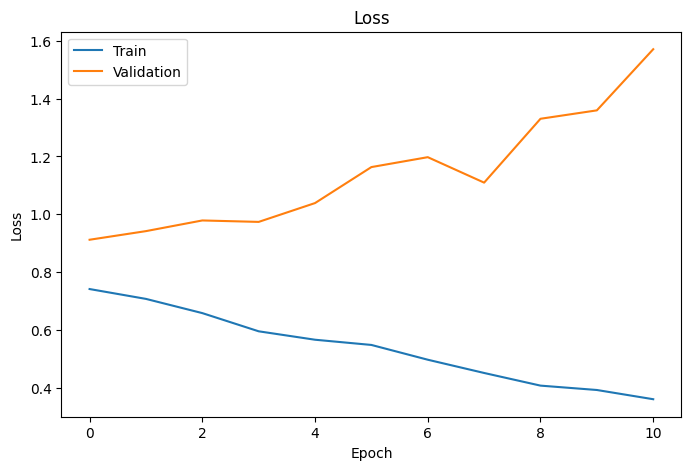

In [39]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"]
)

plt.plot(
    history.history["val_loss"]
)

plt.title(
    "Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.legend(
    [
        "Train",
        "Validation"
    ]
)

plt.show()

In [40]:
test_loss, test_accuracy = model.evaluate(
    test_ds
)

print(
    "Test Accuracy:",
    test_accuracy
)

119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.5970 - loss: 0.9120
Test Accuracy: 0.597046434879303


In [41]:
import numpy as np

pred_probs = model.predict(
    test_ds
)

y_pred = np.argmax(
    pred_probs,
    axis=1
)

119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step


In [42]:
y_true = []

for images, labels in test_ds:

    y_true.extend(
        labels.numpy()
    )

y_true = np.array(
    y_true
)

In [43]:
print(
    len(y_true),
    len(y_pred)
)

948 948


In [44]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

In [45]:
precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(
    "Precision:",
    precision
)

print(
    "Recall:",
    recall
)

print(
    "F1 Score:",
    f1
)

Precision: 0.5829664083221734
Recall: 0.5970464135021097
F1 Score: 0.5802230598565137


In [46]:
from sklearn.metrics import (
    confusion_matrix
)

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[397  40  67]
 [103  71  18]
 [126  28  98]]


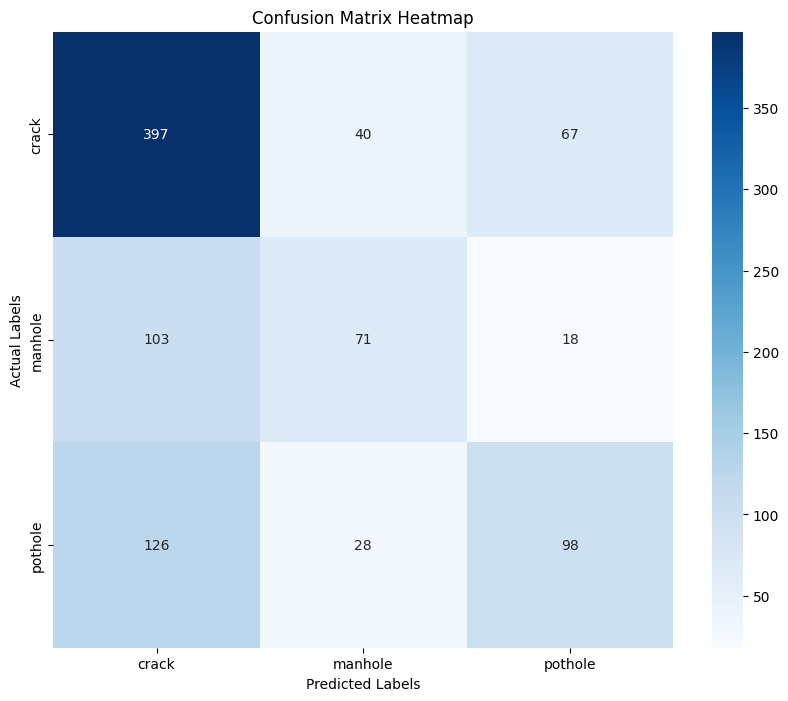

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred
)

# Plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,          # show numbers
    fmt="d",             # integer values
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title(
    "Confusion Matrix Heatmap"
)

plt.xlabel(
    "Predicted Labels"
)

plt.ylabel(
    "Actual Labels"
)

plt.show()

In [48]:
from sklearn.metrics import (
    classification_report
)

print(

classification_report(

y_true,

y_pred,

target_names=encoder.classes_

)

)

              precision    recall  f1-score   support

       crack       0.63      0.79      0.70       504
     manhole       0.51      0.37      0.43       192
     pothole       0.54      0.39      0.45       252

    accuracy                           0.60       948
   macro avg       0.56      0.52      0.53       948
weighted avg       0.58      0.60      0.58       948



In [50]:
wrong_idx = np.where(
    y_true != y_pred
)[0]

print(
    "Wrong Predictions:",
    len(wrong_idx)
)

Wrong Predictions: 382


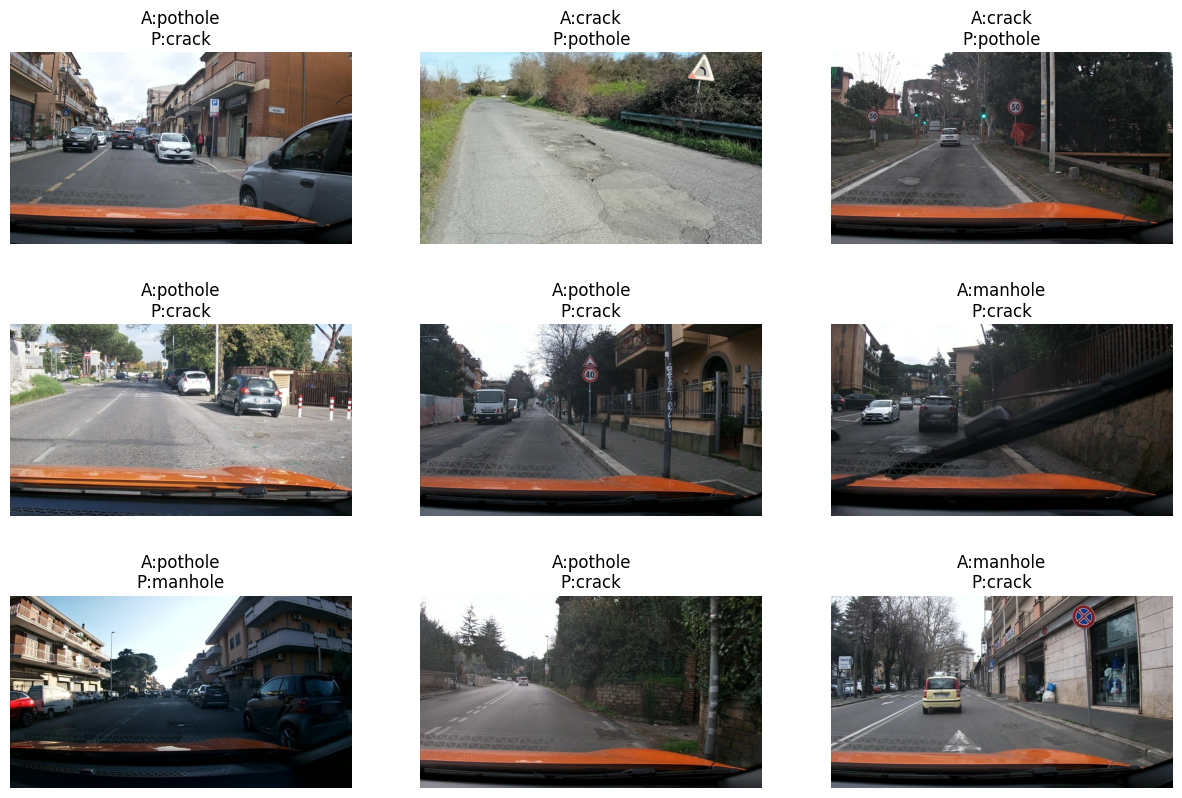

In [51]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(15,10)
)

for i, idx in enumerate(
    wrong_idx[:9]
):

    img = tf.io.read_file(
        test_df.iloc[idx]["path"]
    )

    img = tf.image.decode_jpeg(
        img,
        channels=3
    )

    plt.subplot(
        3,
        3,
        i+1
    )

    plt.imshow(
        img.numpy().astype("uint8")
    )

    actual = (
        encoder.inverse_transform(
            [y_true[idx]]
        )[0]
    )

    predicted = (
        encoder.inverse_transform(
            [y_pred[idx]]
        )[0]
    )

    plt.title(
        f"A:{actual}\nP:{predicted}"
    )

    plt.axis(
        "off"
    )

plt.show()

In [52]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[397  40  67]
 [103  71  18]
 [126  28  98]]


In [81]:
from google.colab import files

uploaded = files.upload()

Saving images.jpg to images (2).jpg


In [82]:
uploaded_file = list(
    uploaded.keys()
)[0]

print(
    uploaded_file
)

images (2).jpg


In [83]:
import tensorflow as tf
import matplotlib.pyplot as plt

IMG_SIZE = 224

img = tf.io.read_file(
    uploaded_file
)

img = tf.image.decode_image(
    img,
    channels=3
)

display_img = img.numpy()

img = tf.image.resize(
    img,
    (
        IMG_SIZE,
        IMG_SIZE
    )
)

img = img / 255.0

img = tf.expand_dims(
    img,
    axis=0
)

In [84]:
prediction = model.predict(
    img
)

pred_class = np.argmax(
    prediction
)

label = (
    encoder.inverse_transform(
        [pred_class]
    )[0]
)

confidence = (
    np.max(
        prediction
    )
    * 100
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


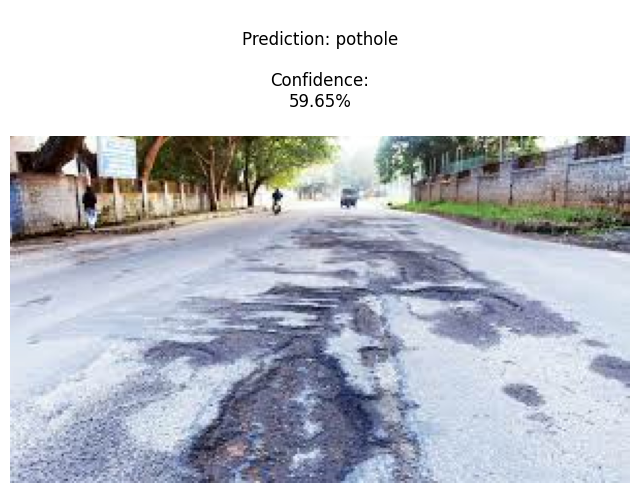

In [85]:
plt.figure(
    figsize=(8,8)
)

plt.imshow(
    display_img
)

plt.axis(
    "off"
)

plt.title(
    f"""
Prediction: {label}

Confidence:
{confidence:.2f}%
"""
)

plt.show()

In [86]:
model.save(
    "road_damage_cnn_model.h5"
)

print(
    "Model Saved"
)

Model Saved


In [87]:
model.save_weights(
    "road_damage_weights.weights.h5"
)

print(
    "Weights Saved"
)

Weights Saved


In [88]:
import json

label_map = {}

for i, name in enumerate(
    encoder.classes_
):
    label_map[i] = name


with open(
    "label_mapping.json",
    "w"
) as f:

    json.dump(
        label_map,
        f,
        indent=4
    )

print(
    label_map
)

{0: 'crack', 1: 'manhole', 2: 'pothole'}
